# Familiar Faces: Industry-Integrated AI Systems Synthesis

## A Human-Supervised Care-Transition Outreach Research Prototype

This notebook integrates three genuinely implemented AI domains:

1. **Data analysis** of real, deidentified hospital encounters
2. **Machine learning** for advisory 30-day readmission prioritization
3. **Generative AI** using live OpenAI Responses API inference with structured output

The project uses the UCI Diabetes 130-US Hospitals dataset. It is an educational research prototype—not a clinical system, eligibility mechanism, or authorization for patient contact.

## Safety and Governance Boundaries

- Public, deidentified research data only
- One eligible encounter per patient to prevent repeat-patient leakage
- Age, gender, and race excluded from model predictors and LLM inputs
- No diagnosis, treatment, medication, eligibility, or autonomous-contact decisions
- Confidence intervals, denominator rules, multiplicity adjustment, and controlled simulations for fairness auditing
- Deterministic safety validation after every LLM output
- Human review required before any possible downstream use

In [1]:
import pandas as pd
from IPython.display import Image, display

from familiar_faces_system import (
    MODEL_FEATURES,
    SYSTEM_BOUNDARIES,
    run_integrated_system,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Model features:", len(MODEL_FEATURES))
print("Human review required:", SYSTEM_BOUNDARIES["human_review_required"])
print("Autonomous contact allowed:", SYSTEM_BOUNDARIES["autonomous_contact_allowed"])

Model features: 20
Human review required: True
Autonomous contact allowed: False


## Integrated Execution

The next cell runs the complete analytic workflow and performs genuine LLM inference. `OPENAI_API_KEY` must be configured in the environment. No protected demographic field or original encounter identifier is sent to the model.

In [2]:
outputs = run_integrated_system(generate_llm=True)

print("End-to-end pipeline executed successfully.")
print("Selected model:", outputs["selected_model_name"])
print("Fairness governance status:", outputs["fairness_status"])

End-to-end pipeline executed successfully.
Selected model: histogram_gradient_boosting
Fairness governance status: MONITOR


## 1. Real-Data Cohort Validation

The source contains 101,766 deidentified encounters from 130 U.S. hospitals and integrated delivery networks between 1999 and 2008. The analytic cohort excludes hospice/expired dispositions and retains the first eligible encounter per patient. This prevents the same patient's encounters from appearing across training and test data.

In [3]:
data = outputs["data"]
validation_summary = pd.DataFrame({
    "validation_item": [
        "eligible encounters",
        "unique patients",
        "duplicate patient identifiers",
        "model features",
        "protected demographics used as predictors",
        "30-day readmission rate",
    ],
    "result": [
        len(data),
        data["patient_nbr"].nunique(),
        int(data["patient_nbr"].duplicated().sum()),
        len(MODEL_FEATURES),
        False,
        data["readmitted_within_30_days"].mean(),
    ],
})
display(validation_summary)
display(outputs["dictionary"])

,validation_item,result
0,eligible encounters,69990
1,unique patients,69990
2,duplicate patient identifiers,0
3,model features,20
4,protected demographics used as predictors,False
5,30-day readmission rate,0.089799


,field_name,role,description
0,encounter_id,identifier,Deidentified hospital encounter identifier.
1,patient_nbr,identifier,Deidentified patient identifier; used only to ...
2,age,fairness_audit_only,Age interval retained only for post-model fair...
3,gender,fairness_audit_only,Recorded gender retained only for post-model f...
4,race,fairness_audit_only,Recorded race retained only for post-model fai...
5,time_in_hospital,model_feature,UCI encounter field used as a time in hospital...
6,num_lab_procedures,model_feature,UCI encounter field used as a num lab procedur...
7,num_procedures,model_feature,UCI encounter field used as a num procedures p...
8,num_medications,model_feature,UCI encounter field used as a num medications ...
9,number_outpatient,model_feature,UCI encounter field used as a number outpatien...


## 2. Descriptive Data Analysis

The descriptive layer examines the observed 30-day readmission rate and prior emergency, inpatient, and outpatient use. These are historical associations, not causal effects.

,metric,value
0,raw_encounters,101766.000000
1,eligible_unique_patient_encounters,69990.000000
2,excluded_or_repeat_encounters,31776.000000
3,30_day_readmission_rate,0.089799
4,mean_prior_emergency_visits,0.103901
5,mean_prior_inpatient_visits,0.176268
6,mean_prior_outpatient_visits,0.279583
7,median_time_in_hospital_days,3.000000


,prior_emergency_band,encounters,readmission_rate,mean_prior_inpatient
0,0,64889,0.087411,0.152275
1,1,3883,0.112542,0.409735
2,2,789,0.134347,0.594423
3,3+,429,0.163170,0.923077


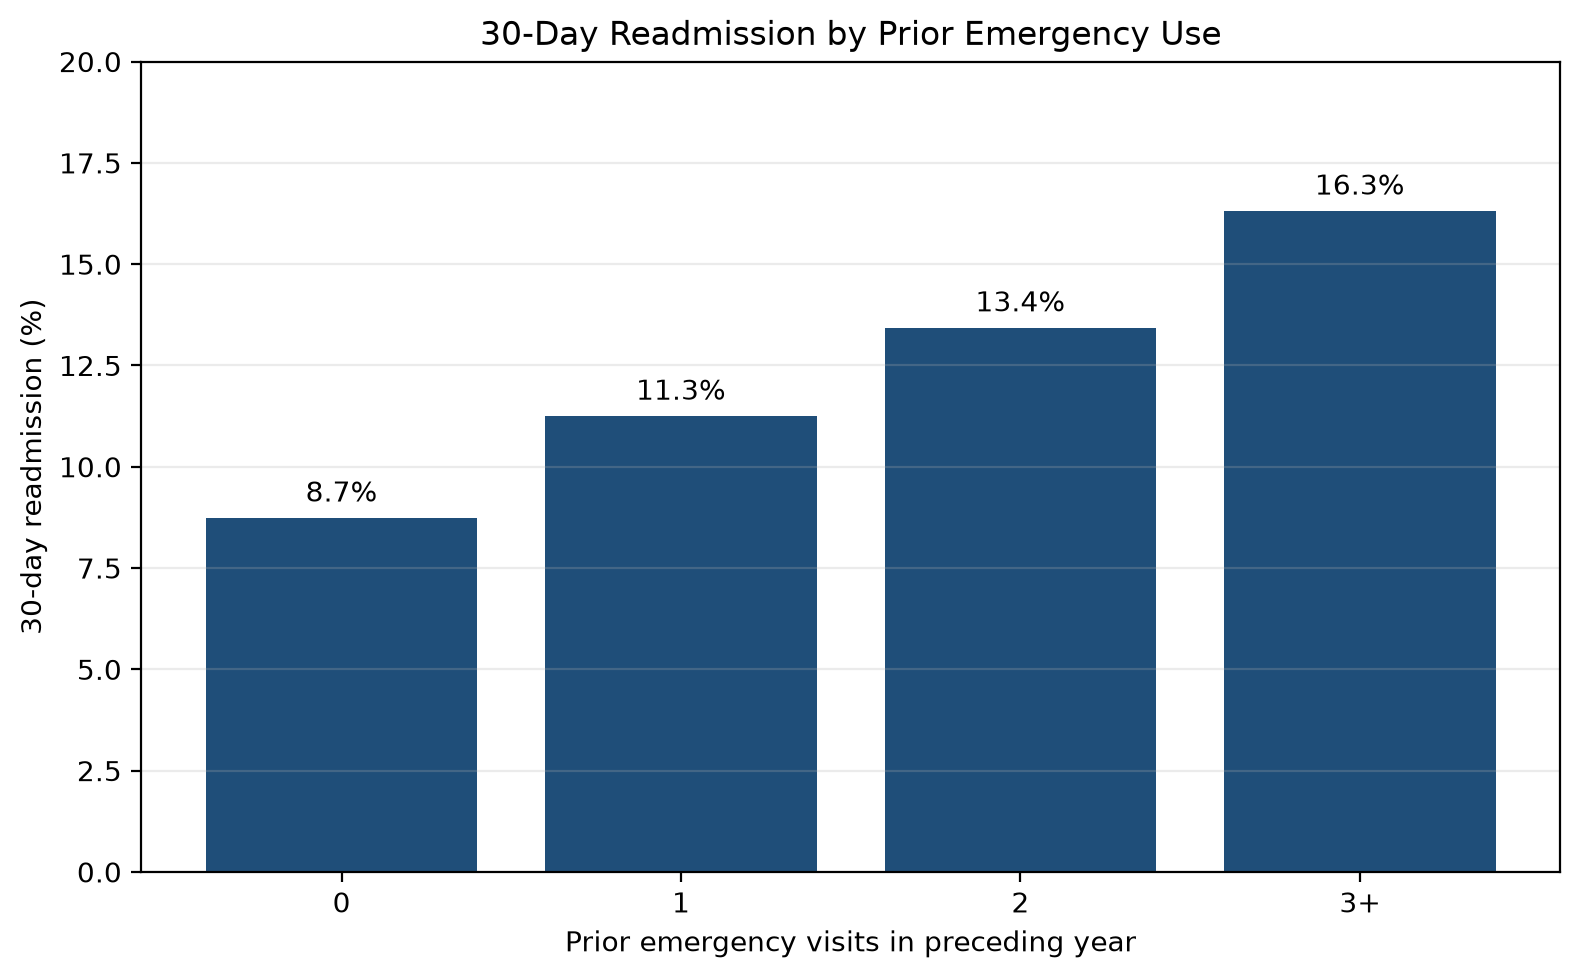

In [4]:
display(outputs["statistical_summary"])
display(outputs["utilization_results"])
display(Image(filename="figures/readmission_by_prior_emergency_use.png", width=750))

## 3. Training-Only Model Selection and Final Evaluation

The final test partition remains untouched while logistic regression, random forest, and histogram gradient boosting are tuned with four-fold cross-validation inside the training data. Average precision is the primary selection metric because 30-day readmission is uncommon, with ROC AUC secondary. Only the selected configuration is evaluated on the final test set. Bootstrap intervals quantify uncertainty. The model output is only a review-queue signal.

,model,train_records,cv_folds,cv_average_precision_mean,cv_average_precision_std,cv_roc_auc_mean,cv_roc_auc_std,best_parameters,test_records,test_positive_rate,roc_auc,average_precision,accuracy,precision,recall,f1,positive_prediction_rate,patient_overlap,selected_for_final_test
0,histogram_gradient_boosting,52492,4,0.168709,0.001099,0.640994,0.004459,"{""model__l2_regularization"": 0.0, ""model__lear...",17498.0,0.089839,0.640938,0.170828,0.910161,0.0,0.0,0.0,0.0,0.0,True
1,random_forest,52492,4,0.168662,0.002391,0.643396,0.004077,"{""model__max_depth"": 10, ""model__min_samples_l...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,logistic_regression,52492,4,0.166387,0.002139,0.639942,0.001908,"{""model__C"": 1.0, ""model__class_weight"": null}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


,metric,point_estimate,confidence_level,lower_bound,upper_bound,bootstrap_samples
0,roc_auc,0.640938,0.95,0.626206,0.655686,1000
1,average_precision,0.170828,0.95,0.156213,0.186033,1000


,feature,importance
0,discharge_disposition_id,0.052893
1,number_inpatient,0.032175
2,admission_source_id,0.002545
3,number_diagnoses,0.002523
4,admission_type_id,0.001742
5,time_in_hospital,0.001643
6,num_lab_procedures,0.001439
7,diabetesMed,0.001396
8,num_medications,0.001113
9,insulin,0.000638


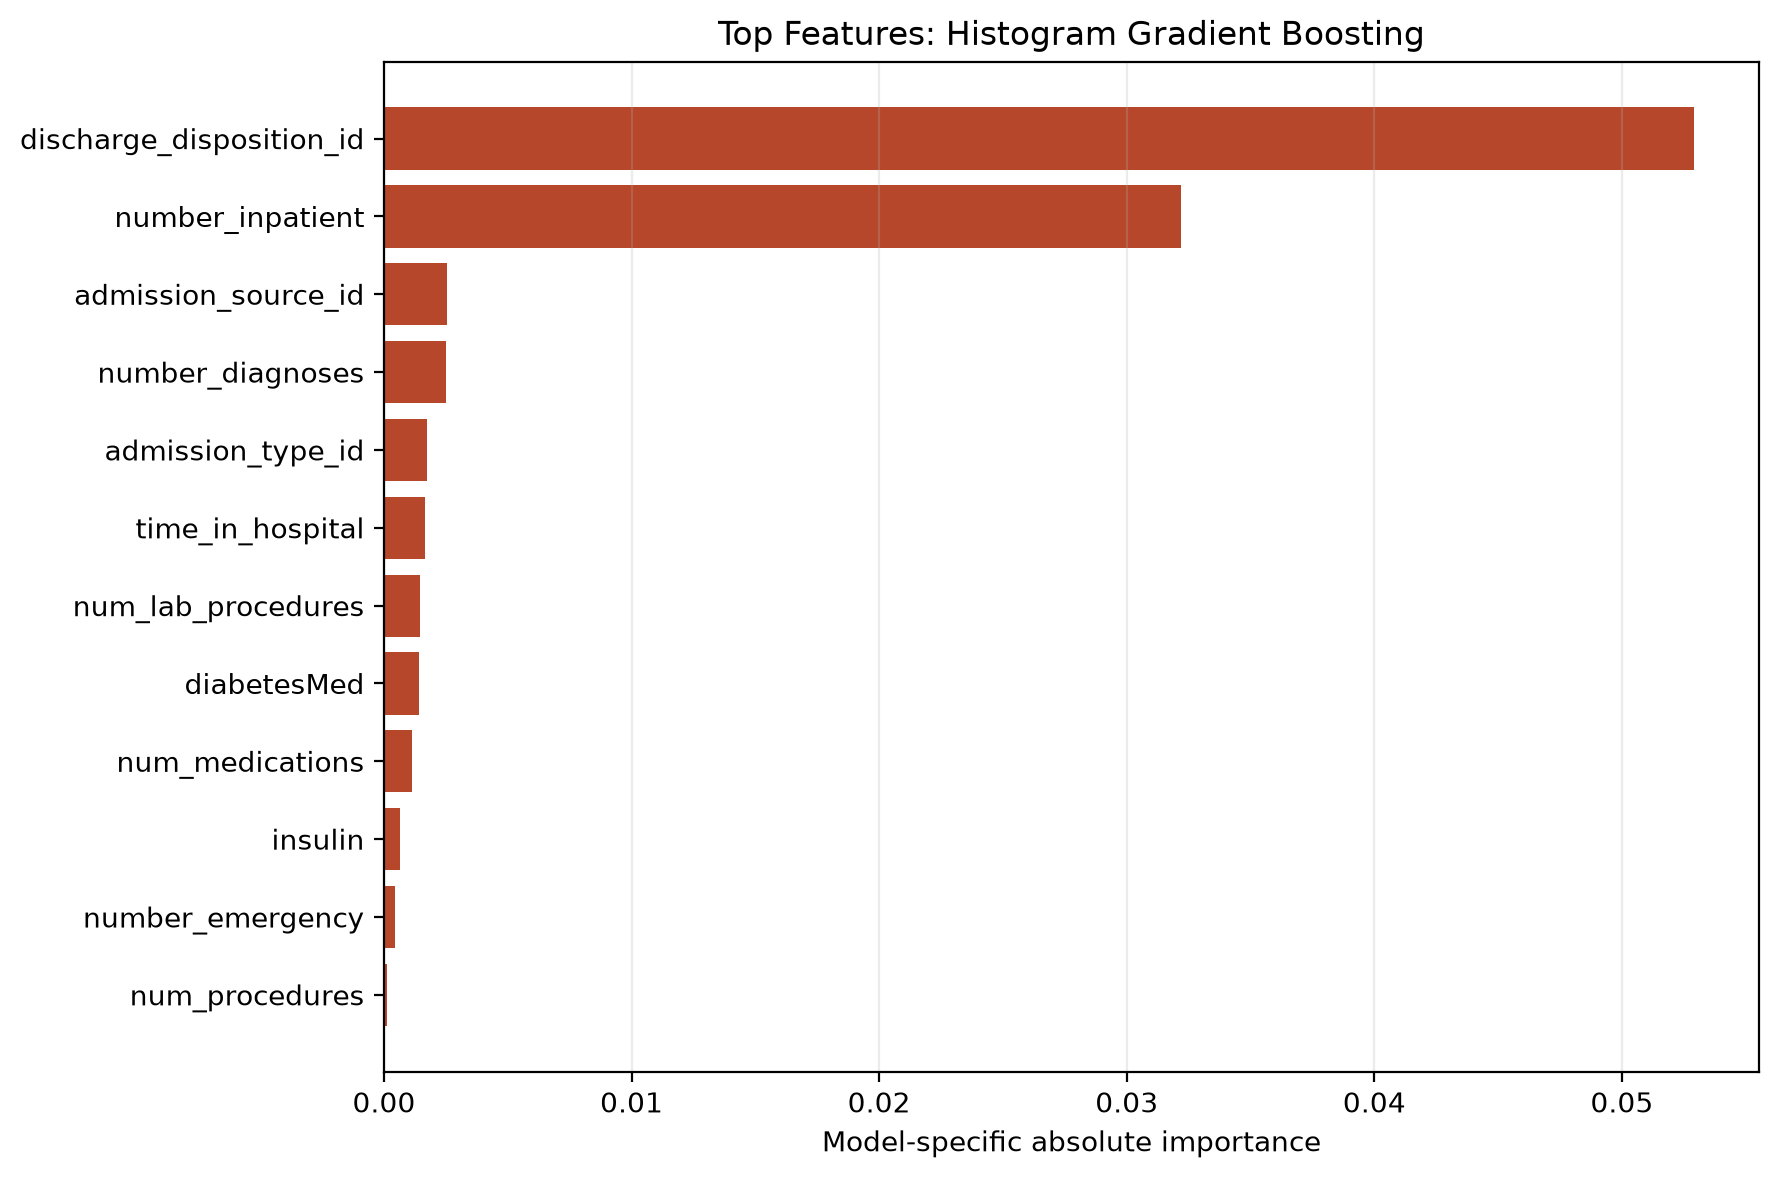

Patient leakage check: PASSED


In [5]:
display(outputs["model_comparison"])
display(outputs["metric_intervals"])
display(outputs["feature_importance"].head(12))
display(Image(filename="figures/selected_model_feature_importance.png", width=800))

selected_row = outputs["model_comparison"].query(
    "selected_for_final_test == True"
).iloc[0]
assert selected_row["patient_overlap"] == 0
assert outputs["model_comparison"]["selected_for_final_test"].sum() == 1
assert outputs["metric_intervals"]["bootstrap_samples"].ge(1000).all()
print("Patient leakage check: PASSED")

## 4. Validated Fairness Audit

Age, gender, and race are audit-only. Each group rate includes a 95% Wilson confidence interval. Comparisons require adequate total and outcome-conditioned denominators, compare each eligible group with the largest reference group, and use Holm adjustment across the full comparison family. A governance review requires both an absolute difference of at least 0.10 and an adjusted p-value below 0.05.

The method is separately tested in 200 independent-null simulations and 200 simulations with a known injected 0.15 review-flag disparity.

In [6]:
display(outputs["fairness_validation"])
review_rows = outputs["fairness_comparisons"].query(
    "governance_action == 'REVIEW_REQUIRED'"
)
display(review_rows)

null_rate = outputs["fairness_validation"].loc[
    outputs["fairness_validation"]["validation_scenario"] == "independent_null_group",
    "trigger_rate",
].iloc[0]
detection_rate = outputs["fairness_validation"].loc[
    outputs["fairness_validation"]["validation_scenario"] == "injected_flag_rate_disparity",
    "trigger_rate",
].iloc[0]
assert null_rate <= 0.05
assert detection_rate >= 0.80
print("Fairness-method validation: PASSED")

,validation_scenario,simulations,target_difference,mean_realized_difference,trigger_rate,interpretation
0,independent_null_group,200,0.00,0.000000,0.0,Estimated familywise false-positive rate acros...
1,injected_flag_rate_disparity,200,0.15,0.150052,1.0,Estimated detection rate for a known disparity.


,audit_field,group,reference_group,metric,group_denominator,reference_denominator,rate_difference,absolute_difference,raw_p_value,eligible_for_comparison,holm_adjusted_p_value,practically_large,statistically_significant,governance_action


Fairness-method validation: PASSED


## 5. Genuine Generative-AI Component

The system sends five demographics-free, deidentified case inputs to an OpenAI model through the Responses API. Structured Outputs enforce the expected schema. A separate deterministic validator rejects protected-demographic language, diagnosis or prescribing language, dose changes, autonomous eligibility/contact language, or missing safety statements.

Passing the automated gate does not authorize use: every draft still requires human review.

In [7]:
generated = outputs["generated_materials"]
generation_summary = pd.DataFrame({
    "metric": [
        "genuine LLM drafts",
        "drafts passing deterministic safety validation",
        "demographic fields sent",
        "demographics detected in outputs",
        "human review required for all",
    ],
    "value": [
        len(generated),
        int(generated["safety_validation_passed"].sum()),
        False,
        bool(generated["demographics_included"].any()),
        bool(generated["human_review_required"].all()),
    ],
})
display(generation_summary)
display(generated[[
    "case_id",
    "case_summary",
    "review_questions",
    "coordination_options",
    "limitations",
    "human_review_notice",
    "safety_violations",
]].head(3))

assert generated["generation_mode"].eq(
    "openai_responses_api_structured_output"
).all()
assert generated["safety_validation_passed"].all()
assert not generated["demographics_included"].any()
print("Generative-AI execution and safety validation: PASSED")

,metric,value
0,genuine LLM drafts,5
1,drafts passing deterministic safety validation,5
2,demographic fields sent,False
3,demographics detected in outputs,False
4,human review required for all,True


,case_id,case_summary,review_questions,coordination_options,limitations,human_review_notice,safety_violations
0,CASE-001,This deidentified research record reports 2 pr...,[Authorized reviewer: verify that the reported...,"[If permitted by the research protocol, route ...",This draft uses only the supplied record field...,Human review required before any use or action.,NONE
1,CASE-002,This deidentified research record reports 0 pr...,[Authorized reviewer: verify that the reported...,"[If permitted by the research protocol, route ...",This draft uses only the supplied record field...,Human review required before any use or action.,NONE
2,CASE-003,This deidentified research record reports 0 pr...,[Authorized reviewer: verify that the reported...,"[If permitted by the research protocol, route ...",This draft uses only the supplied record field...,Human review required before any use or action.,NONE


Generative-AI execution and safety validation: PASSED


## 6. Integrated System Summary

The summary connects real-data analysis, empirical model comparison, validated fairness governance, genuine LLM inference, deterministic safety checks, and the terminal human-review boundary.

In [8]:
display(outputs["integrated_summary"])

assert outputs["generated_materials"] is not None
assert SYSTEM_BOUNDARIES["human_review_required"]
assert not SYSTEM_BOUNDARIES["autonomous_contact_allowed"]
print("Integrated notebook validation: PASSED")

,system_metric,value
0,real_deidentified_encounters,69990
1,unique_patients,69990
2,model_features,20
3,protected_demographics_used_as_model_features,False
4,selected_model,histogram_gradient_boosting
5,test_records,17498
6,selected_model_roc_auc,0.640938
7,selected_model_average_precision,0.170828
8,fairness_governance_status,MONITOR
9,fairness_comparisons_requiring_review,0


Integrated notebook validation: PASSED


## Limitations and Responsible Use

- The dataset is historical (1999–2008), limited to encounters involving diabetes, and not representative of a present-day community-paramedicine population.
- Readmission is an imperfect proxy for whether outreach is appropriate or beneficial.
- The model is not calibrated or externally validated for operational decisions.
- The protected-group audit is observational and cannot establish the cause of a disparity.
- Null and injected-disparity simulations validate the audit rule under defined conditions, not every possible population or harm.
- LLM drafts may still be incomplete, misleading, or contextually inappropriate after automated checks.
- No component may diagnose, recommend treatment, determine eligibility, or initiate contact.
- Clinical, legal, privacy, security, accessibility, workflow, stakeholder, and prospective-effectiveness reviews would be required before any real-world research pilot.